### Vector potential of current carrying winding inside iron core

Lets put 100 A urrent through wire and see what happends in air and iron domains

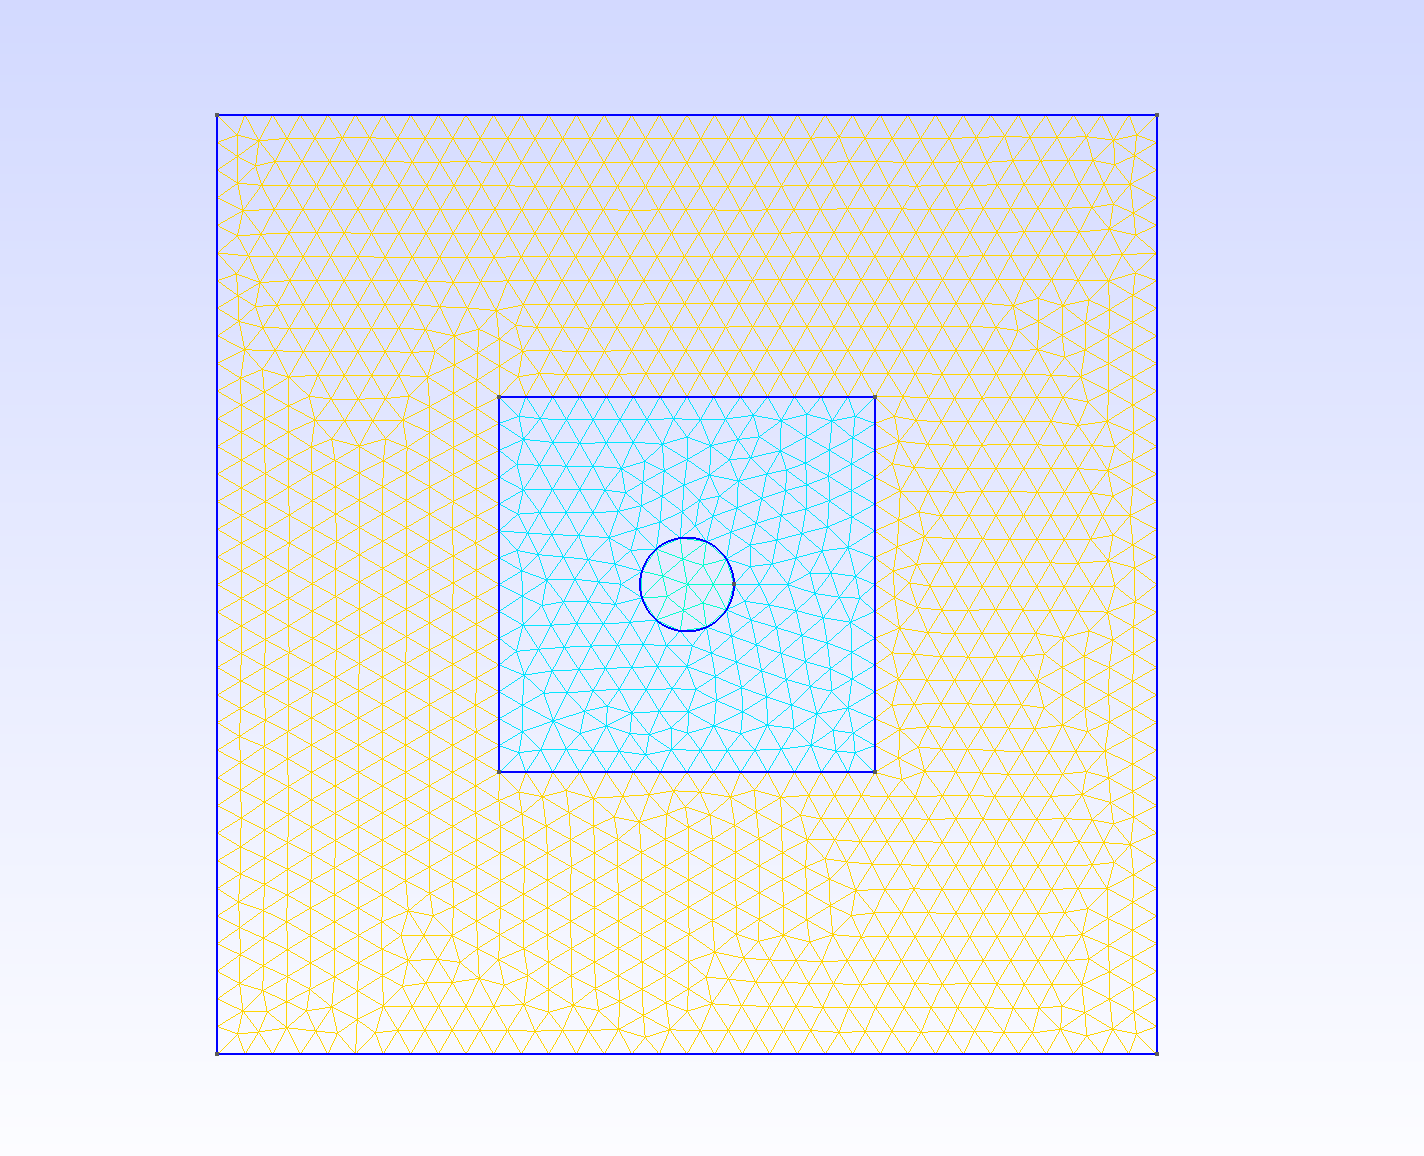



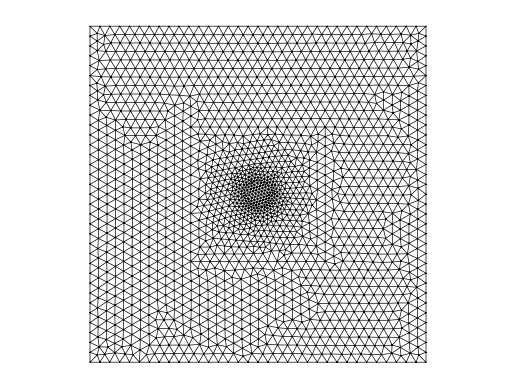

In [43]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/wire_in_iron.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

Get triangualr elements and first order basis functions. We need to define own basis for 'air' and 'wire' and 'iron' domains, because the J=0 in air and iron, and J = Jz at wire. 
Also permeability is different in iron

In [44]:
e = ElementTriP1()
basis = Basis(mesh, e)
basis_wire = basis.with_elements(mesh.subdomains["wire"])
basis_air = basis.with_elements(mesh.subdomains["air"])
basis_iron = basis.with_elements(mesh.subdomains["iron"])


print(basis_wire)
print(basis_air)
print(basis_iron)
print(basis)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 1811
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2362
  Number of DOFs: 1811
  Size: 510192 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 910
  Number of DOFs: 1811
  Size: 196560 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 3484
  Number of DOFs: 1811
  Size: 752544 B


Bilinear and linear forms, from weak formulation. Now the mu is a function, wheter we are in iron or air. Alos J is only in wire, else 0


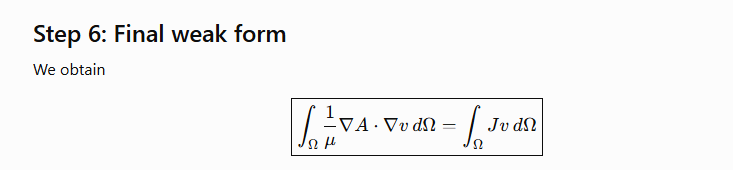

Assemble the system

In [45]:
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

wire_area = area.assemble(basis_wire)
air_area = area.assemble(basis_air)
iron_area = area.assemble(basis_iron)

print("Wire area: ", wire_area)
print("Air area: ", air_area)
print("Iron area: ", iron_area)

Wire area:  0.007803612880645131
Air area:  0.8400000000000001
Iron area:  0.15219638711935485


Areas are correct!

In [66]:

# w.mu little coonfusing but it just wraps the permeability to some variable w

@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def rhs(v, w):
    return w.J * v


mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_wire = mu0
mu_iron = 1000 * mu0


S_mat = laplace.assemble(basis_air, mu=mu_air)
S_mat += laplace.assemble(basis_wire, mu=mu_wire)
S_mat += laplace.assemble(basis_iron, mu=mu_iron)

# Wire
I_z = 100 # Amperes
J_wire = I_z/wire_area
print(J_wire)

# other regions dont have current
J_iron = 0
J_air =  0

b = rhs.assemble(basis_wire, J = J_wire)
b +=  rhs.assemble(basis_air, J = J_air)
b +=  rhs.assemble(basis_iron, J = J_iron)


12814.57723870753


Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [60]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())   


Solve & Visualize Az = vector pootential

[0.         0.         0.         ... 0.01957523 0.00817612 0.00616842]


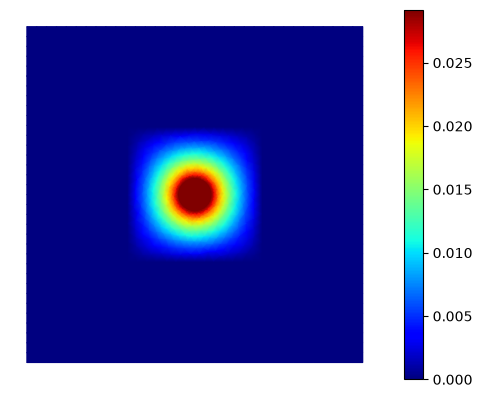

In [61]:
A_z = solve(S_mat, b)

print(A_z)

def visualize():
    from skfem.visuals.matplotlib import plot
    return plot(mesh, A_z, shading='gouraud', colorbar=True)

if __name__ == "__main__":
    visualize().show()

In [ ]:
import numpy as np

# COMSOL values
Az_comsol = np.array([
    5.3799754568608905E-6,
	1.1575139972320832E-5,
	0.008890839648236825,
	0.02945827664371554,
	0.008890382545959145,
	1.1574988836562367E-5,
	5.379984060259168E-6,
	1.2237413816733184E-5,
	1.2237422351444181E-5,
	1.817696226264754E-5,
	0.029455057185991153
])

# Points
points = np.array([
    [0.20, 0.20],
    [0.30, 0.30],
    [0.40, 0.40],
    [0.50, 0.50],
    [0.60, 0.60],
    [0.70, 0.70],
    [0.80, 0.80],
    [0.50, 0.20],
    [0.20, 0.50],
    [0.70, 0.40],
    [0.52, 0.52]
])

Az_fem = []

# Evaluate FEM solution
for x, y in points:
    P = basis.probes(np.array([[x], [y]]))
    Az_fem.append((P @ A_z)[0])

Az_fem = np.array(Az_fem)

# Errors
abs_error = np.abs(Az_fem - Az_comsol)
rel_error = 100 * abs_error / np.abs(Az_comsol)

# Print table
print(
    f"{'x':>5} {'y':>5} "
    f"{'FEM':>14} {'COMSOL':>14} "
    f"{'Abs. Error':>14} {'Rel. Error %':>14}"
)
print("-"*80)

for i, (x, y) in enumerate(points):
    print(
        f"{x:5.2f} {y:5.2f} "
        f"{Az_fem[i]:14.6e} "
        f"{Az_comsol[i]:14.6e} "
        f"{abs_error[i]:14.6e} "
        f"{rel_error[i]:14.3f}"
    )

print("\nSummary")
print("-------")
print(f"Mean relative error : {rel_error.mean():.3f} %")
print(f"Maximum relative error : {rel_error.max():.3f} %")
print(f"RMS relative error : {np.sqrt(np.mean(rel_error**2)):.3f} %")

    x     y            FEM         COMSOL     Abs. Error   Rel. Error %
--------------------------------------------------------------------------------
 0.20  0.20   5.344893e-06   5.379711e-06   3.481820e-08          0.647
 0.30  0.30   1.151477e-05   1.157339e-05   5.862854e-08          0.507
 0.40  0.40   8.783016e-03   3.550668e-02   2.672366e-02         75.264
 0.50  0.50   2.917596e-02   1.177443e-01   8.856838e-02         75.221
 0.60  0.60   8.834350e-03   3.550485e-02   2.667050e-02         75.118
 0.70  0.70   1.151406e-05   1.157324e-05   5.918230e-08          0.511
 0.80  0.80   5.344973e-06   5.379720e-06   3.474719e-08          0.646
 0.50  0.20   1.218321e-05   1.223821e-05   5.500529e-08          0.449
 0.20  0.50   1.215259e-05   1.223822e-05   8.563220e-08          0.700
 0.70  0.40   1.803647e-05   1.817740e-05   1.409267e-07          0.775
 0.52  0.52   2.917277e-02   1.177411e-01   8.856834e-02         75.223

Summary
-------
Mean relative error : 27.733 %
Maximum

Now we compute Bx and By with partial derivatives to plot B field

(2, 1811)
(3, 3484)
(2, 3, 3484)
(2, 3484)


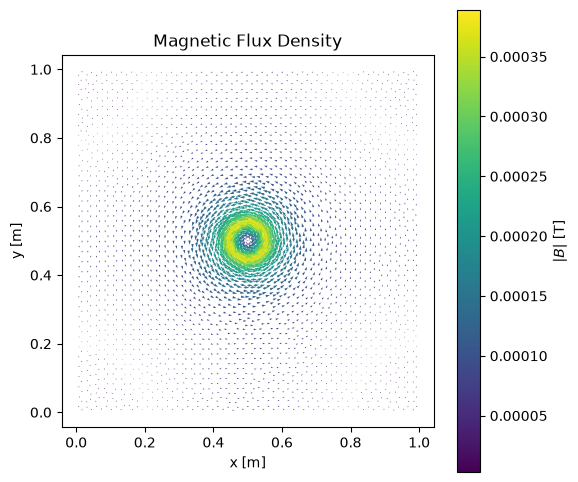

In [57]:
# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)

centers = mesh.p[:, mesh.t].mean(axis=2)

print(mesh.p.shape)
print(mesh.t.shape)

print(mesh.p[:, mesh.t].shape)
centers = mesh.p[:, mesh.t].mean(axis=1)
print(centers.shape)

fig, ax = plt.subplots(figsize=(6, 6))

q = ax.quiver(
    centers[0],
    centers[1],
    Bx_elem,
    By_elem,
    np.sqrt(Bx_elem**2 + By_elem**2),   # color arrows by |B|
    cmap="viridis"
)

ax.set_title("Magnetic Flux Density")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

plt.show()




Bnorm for each element


Number of air elements: 2362
Min |B| in air : 2.907520e-06 T
Max |B| in air : 9.809050e-05 T
Mean |B| in air: 4.802583e-05 T


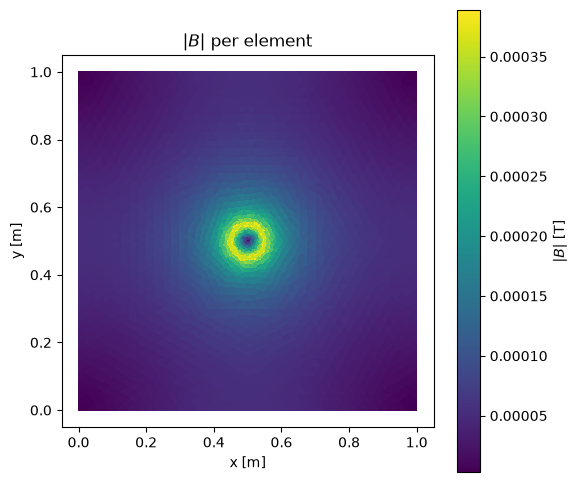

In [58]:
Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)

# Check is it zero


# Element indices belonging to the air region
air_elems = basis_air.tind

print(f"Number of air elements: {len(air_elems)}")

B_air = Bnorm_elem[air_elems]

print(f"Min |B| in air : {B_air.min():.6e} T")
print(f"Max |B| in air : {B_air.max():.6e} T")
print(f"Mean |B| in air: {B_air.mean():.6e} T")

import matplotlib.tri as mtri

tri = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

fig, ax = plt.subplots(figsize=(6,6))

pc = ax.tripcolor(
    tri,
    facecolors=Bnorm_elem,
    edgecolors='none',
    cmap='viridis'
)

ax.set_title(r"$|B|$ per element")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")

fig.colorbar(pc, ax=ax, label=r"$|B|$ [T]")

plt.show()

The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.


In [28]:
# Build connectivity. This help to find elements that share nodes. Then we know which gradient values to average for specific node.
node_to_elements = [[] for _ in range(mesh.nvertices)]

for elem in range(mesh.nelements):

    for node in mesh.t[:, elem]:

        node_to_elements[node].append(elem)


Bx_node = np.zeros(mesh.nvertices)
By_node = np.zeros(mesh.nvertices)



for node in range(mesh.nvertices):
    # all elements that share 'node'
    elems = node_to_elements[node]

    # nodal averaged values for Bx and By
    Bx_node[node] = np.mean(Bx_elem[elems])
    By_node[node] = np.mean(By_elem[elems])

B_norm = np.sqrt(Bx_node**2+By_node**2)

print(Bx_node.shape)
print(B_norm.shape)


(1811,)
(1811,)


Compute B-norm and plot



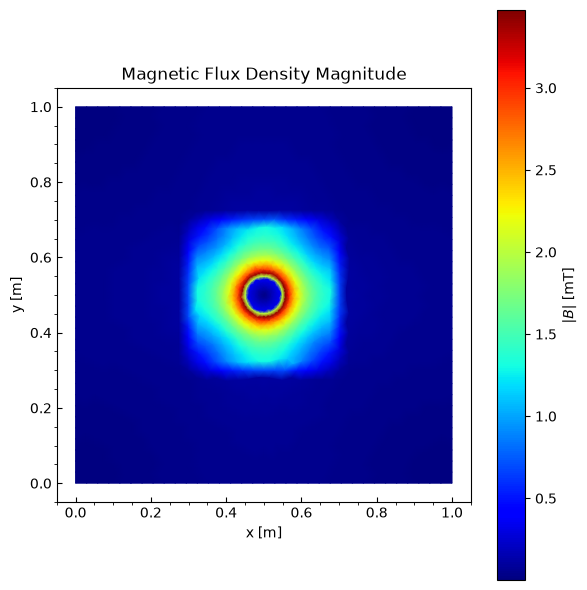

In [29]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
def visualize():
    fig, ax = plt.subplots(figsize=(6, 6))

    plot(
        mesh,
        1000 * B_norm,
        ax=ax,              # <-- important
        shading='gouraud',
        colorbar=True
    )

    ax.set_title("Magnetic Flux Density Magnitude")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

    ax.tick_params(direction='in')
    ax.minorticks_on()

    # Colorbar is a second axes in the figure
    cbar = fig.axes[-1]
    cbar.set_ylabel(r"$|B|$ [mT]")

    fig.tight_layout()

if __name__ == "__main__":
    visualize()
    plt.show()

Lets evalueate the Bnorm at coordinate (0.7, 0.8). Then we compare this with analytical Biot-Savart law


In [51]:
x = 0.7
y = 0.8

points = np.array([[x],
                   [y]])

# Create interpolation matrix
P = basis.probes(points)

# Interpolate the nodal fields
Bx = (P @ Bx_node)[0]
By = (P @ By_node)[0]

# same than sqrt(Bx^2+By^2)
Bnorm_point = np.hypot(Bx, By)

print(f"Bnorm at point ({x}, {y}) = {1000*Bnorm_point} mT")



Bnorm at point (0.7, 0.8) = 0.05229984596286898 mT


Lets compare this to analytical Biot-Savart law.


In [42]:
r = np.sqrt((x-0.5)**2+(y-0.5)**2)

mu0 = 4*np.pi*1e-7
I = 100
B_biotsavart = mu0*I/(2*np.pi*r)

print(f"Analytical Bnorm at point ({x}, {y}) = {1000*B_biotsavart} mT")

Analytical Bnorm at point (0.7, 0.8) = 0.05547001962252291 mT


Our solutions differs 0.046752 mT,  so it is capturing the phenomena with okay accuracy even with 1270 DOFs